In [78]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# data handling
from sklearn.preprocessing import StandardScaler, OneHotEncoder
#!pip3 install imblearn
#!pip3 install -U scikit-learn imbalanced-learn
from imblearn.over_sampling import SMOTE  # https://www.geeksforgeeks.org/machine-learning/smote-for-imbalanced-classification-with-python/
from imblearn.pipeline import Pipeline

# model building
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier #https://scikit-learn.org/stable/modules/feature_selection.html
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier

#!pip install xgboost
from xgboost import XGBClassifier

from sklearn.decomposition import PCA

# model evaluation
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, make_scorer


# hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV




# Fetal Health Classification Modeling
This notebook runs through developing fetal health classification models using the cardiotocography data from UCI. Cardiotocography (CTG) is a vital monitoring technique used to record the fetal heart rate and uterine activity during pregnancy. The fetal condition is categorized into 3 classes: Normal (N), Suspicious (S), and Pathologic (P). While monitoring CTG can provide vital information about fetal well-being, it's often subjective, susceptible to misreading, and prone to inter-observer variability. To address these challenges, this study investigates various machine learning models to improve classification performance and reduce human error.

## Data Preprocessing

In [55]:
# read in data
ctg = pd.read_excel('ctg_rawdata.xlsx', header=1)
ctg = ctg.drop(0)

In [56]:
display(ctg.head())

print(f"Size of raw dataframe: {ctg.shape}")
print(f"\n All columns in raw dataframe: {ctg.columns}")

,FileName,Date,SegFile,b,e,LBE,LB,AC,FM,UC,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
1,Variab10.txt,1996-12-01,CTG0001.txt,240.0,357.0,120.0,120.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,2.0
2,Fmcs_1.txt,1996-05-03,CTG0002.txt,5.0,632.0,132.0,132.0,4.0,0.0,4.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
3,Fmcs_1.txt,1996-05-03,CTG0003.txt,177.0,779.0,133.0,133.0,2.0,0.0,5.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
4,Fmcs_1.txt,1996-05-03,CTG0004.txt,411.0,1192.0,134.0,134.0,2.0,0.0,6.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
5,Fmcs_1.txt,1996-05-03,CTG0005.txt,533.0,1147.0,132.0,132.0,4.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0


Size of raw dataframe: (2129, 40)

 All columns in raw dataframe: Index(['FileName', 'Date', 'SegFile', 'b', 'e', 'LBE', 'LB', 'AC', 'FM', 'UC',
       'ASTV', 'MSTV', 'ALTV', 'MLTV', 'DL', 'DS', 'DP', 'DR', 'Width', 'Min',
       'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance',
       'Tendency', 'A', 'B', 'C', 'D', 'E', 'AD', 'DE', 'LD', 'FS', 'SUSP',
       'CLASS', 'NSP'],
      dtype='object')


There are 40 variables (including the classification result) in the raw dataset. Following the description of the cardiotocography data (https://archive.ics.uci.edu/dataset/193/cardiotocography), will focus on 23 variables. 

- LB : FHR baseline (beats per minute)
- AC : # of accelerations per second
- FM : # of fetal movements per second
- UC : # of uterine contractions per second
- DL : # of light decelerations per second
- DS : # of severe decelerations per second
- DP : # of prolongued decelerations per second
- ASTV : percentage of time with abnormal short term variability
- MSTV : mean value of short term variability
- ALTV : percentage of time with abnormal long term variability
- MLTV : mean value of long term variability
- Width : width of FHR histogram
- Min : minimum of FHR histogram
- Max : Maximum of FHR histogram
- Nmax : # of histogram peaks
- Nzeros : # of histogram zeros
- Mode : histogram mode
- Mean : histogram mean
- Median : histogram median
- Variance : histogram variance
- Tendency : histogram tendency
- CLASS : FHR pattern class code (1 to 10) 
- NSP : fetal state class code (N=normal; S=suspect; P=pathologic)

In [57]:
# Focusing on 23 variables
feature = ['LB','AC','FM','UC','DL','DS','DP','ASTV','MSTV', 'ALTV','MLTV','Width','Min','Max','Nmax','Nzeros', 'Mode','Mean','Median','Variance','Tendency']
target = ['NSP']

ctg = ctg[feature + target]
print(f"Types of variables: \n{ctg.dtypes}")

# masking target column to class value N, S, P
def change_NSP(x=int):
    if x == 1: 
        return "N"
    elif x == 2:
        return "S"
    else: 
        return "P"
    
ctg["NSP"] = ctg["NSP"].apply(change_NSP)

print(f"\nTypes of variables after mapping: \n{ctg.dtypes}")


Types of variables: 
LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Min         float64
Max         float64
Nmax        float64
Nzeros      float64
Mode        float64
Mean        float64
Median      float64
Variance    float64
Tendency    float64
NSP         float64
dtype: object

Types of variables after mapping: 
LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Min         float64
Max         float64
Nmax        float64
Nzeros      float64
Mode        float64
Mean        float64
Median      float64
Variance    float64
Tendency    float64
NSP          object
dtype: object


Checking types of every variable, confirm that all variables are float type. After masking, the target variable is an object type. 

### Null handling

In [58]:
# check number of null values
print(f"Count of null values in each column: \n{ctg.isnull().sum()}")
print(f"\nPercentage of missing values: \n{ctg.isnull().sum() / len(ctg)}")

Count of null values in each column: 
LB          3
AC          3
FM          2
UC          2
DL          1
DS          1
DP          1
ASTV        2
MSTV        2
ALTV        2
MLTV        2
Width       3
Min         3
Max         3
Nmax        3
Nzeros      3
Mode        3
Mean        3
Median      3
Variance    3
Tendency    3
NSP         0
dtype: int64

Percentage of missing values: 
LB          0.001409
AC          0.001409
FM          0.000939
UC          0.000939
DL          0.000470
DS          0.000470
DP          0.000470
ASTV        0.000939
MSTV        0.000939
ALTV        0.000939
MLTV        0.000939
Width       0.001409
Min         0.001409
Max         0.001409
Nmax        0.001409
Nzeros      0.001409
Mode        0.001409
Mean        0.001409
Median      0.001409
Variance    0.001409
Tendency    0.001409
NSP         0.000000
dtype: float64


The percentages of null values in each column are under the general rule of thumb: 10% rule. We can safely drop all null values. In fact, the record number after dropping the null matches the description of dataset. 

In [59]:
ctg = ctg.dropna()
print(f"Size of dataframe after dropping null rows: {ctg.shape}") # matches the description 2126 data

Size of dataframe after dropping null rows: (2126, 22)


### Class Imbalance

In [60]:
# Check class imbalance
print(f"Check NSP class imbalance: \n{ctg['NSP'].value_counts()}")
print(f"\nClass proportion: \n{ctg['NSP'].value_counts(normalize=True)}")

Check NSP class imbalance: 
NSP
N    1655
S     295
P     176
Name: count, dtype: int64

Class proportion: 
NSP
N    0.778457
S    0.138758
P    0.082785
Name: proportion, dtype: float64


There are noticable differences among the value counts of N, S, P classes. N class takes up around 77% of the whole dataset while P class only takes up around 8%. This indicates we may need to apply imbalance technique to ensure there are enough data for algorithms to detect distinct pattern for all classes. 

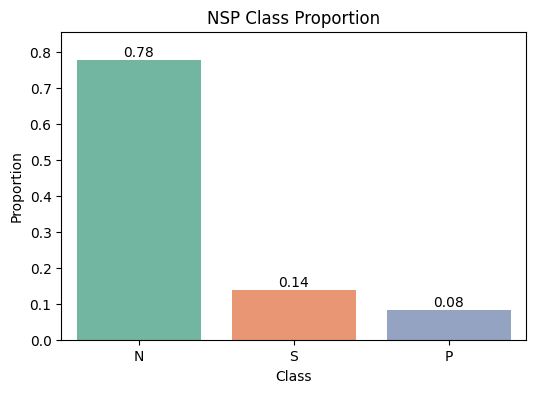

In [61]:
dist = ctg['NSP'].value_counts(normalize=True)

plt.figure(figsize=(6,4))

ax = sns.barplot(x=dist.index, 
                 y=dist.values,
                 hue=dist.index, 
                 palette = 'Set2')

for i, v in enumerate(dist.values):
    ax.text(i, v + 0.01, f"{v:.2f}", ha='center')

ax.margins(y=0.1)

plt.title("NSP Class Proportion")
plt.xlabel("Class")
plt.ylabel("Proportion")

plt.show()


### Correlation Analysis

Highly correlated features may negatively affect classification performance. Although ensemble-based models such as Random Forest and XGBoost are relatively insensitive to redundant predictors, strong correlations between input variables can cause multicollinearity in simpler linear models, leading to unstable coefficient estimates and reduced model interpretability.

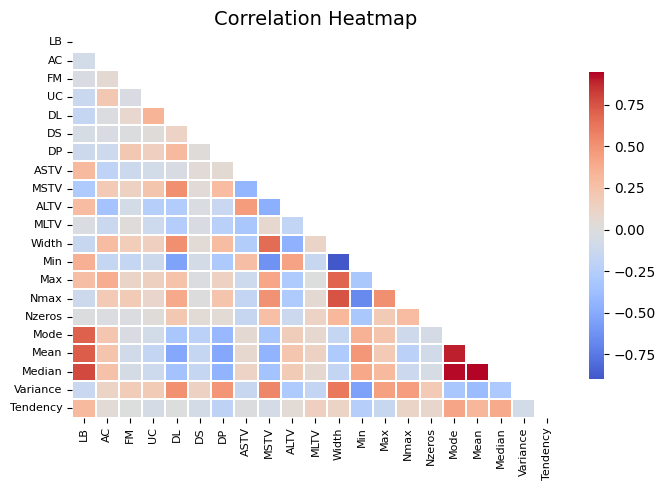

In [62]:
corr = ctg.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(7,5))
ax = sns.heatmap(corr, 
            mask=mask,
            cmap='coolwarm',
            center=0,
            linewidths=.3,
            cbar_kws={"shrink": 0.8})
ax.tick_params(labelsize=8)
plt.title("Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

Looking at the correlation heatmap, we can quickly see that variables "Mean", "Median", "Mode" have strong positive correlations and "Min", "Width" variables have a strong negative correlation. Other variables in general have lower correlation across other variables. We can use threhold of 0.9 to remove highly correlated variables. 

In [63]:
# drop high correlated variables
upper = corr.where(np.triu(np.ones_like(corr, dtype=bool), k=1))

to_drop = [col for col in upper.columns if any(abs(upper[col]) > 0.9)]
ctg_clean = ctg.drop(columns=to_drop)

In [64]:
print(f"Columns after dropping high correlated variables: \n{ctg_clean.columns}")
print(f"Number of variables: {len(ctg_clean.columns)}")


Columns after dropping high correlated variables: 
Index(['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV',
       'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean',
       'Variance', 'Tendency', 'NSP'],
      dtype='object')
Number of variables: 21


Column "Median" is dropped based on high correlation threshold. 

## Train Test Split

In [65]:
X = ctg_clean.drop(columns='NSP')
y = ctg_clean['NSP']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, 
    stratify=y,
    random_state=42
)

print(f"Number of train set: {X_train.shape}")
print(f"Number of test set: {X_test.shape}")

Number of train set: (1700, 20)
Number of test set: (426, 20)


### Feature Scaling

In [66]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### PCA Feature Selection

Since the dataset contains 20 physiological variables, PCA was applied as a dimensionality reduction technique to compress the feature space before training simple linear classification models such as Logistic Regression and SVM. A separate PCA-transformed dataset was created to evaluate model performance with reduced dimensionality.

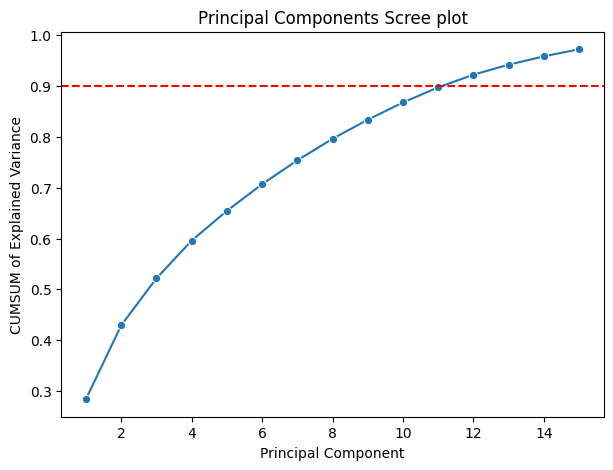

In [67]:
# scaling features

# PCA 
pca = PCA()
pca.fit(X_train_scaled)

pc_values = np.arange(pca.n_components_) + 1 
cumsum_v = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(7,5))

sns.lineplot(
    x=pc_values[:15], 
    y=cumsum_v[:15], 
    marker='o')
plt.axhline(0.9 ,linestyle='--', color='red')
plt.title('Principal Components Scree plot')
plt.xlabel('Principal Component')
plt.ylabel('CUMSUM of Explained Variance')

plt.show()



Based on the scree plot, the first 11 principal components explain approximately 90% of the total variance. Therefore, reducing the dimensionality to 11 components significantly compresses the feature space while retaining most of the information in the dataset.

In [68]:
pca = PCA(n_components=11)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"New PCA reduced sample shape: {X_train_pca.shape}")

New PCA reduced sample shape: (1700, 11)


After PCA reduction, the feature data reduced to 11 variables. 

## Handling Class Imbalance

To handle significant class imbalance discussed during preprocessing, we implement SMOTE to the train sets. By applying SMOTE, classes with smaller counts will be magnified using the pattern. 

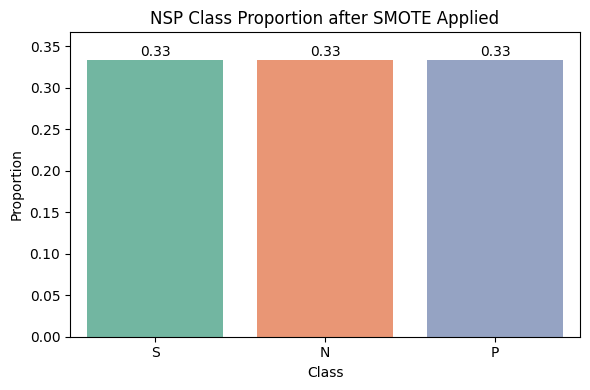

# training data before SMOTE:  NSP
N    1323
S     236
P     141
Name: count, dtype: int64

# training data after SMOTE:  NSP
S    1323
N    1323
P    1323
Name: count, dtype: int64


In [69]:
# SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train,y_train)
X_train_scaled_smote, y_train_scaled_smote = smote.fit_resample(X_train_scaled, y_train)
X_train_pca_smote, y_train_pca_smote = smote.fit_resample(X_train_pca, y_train)

y_values = pd.Series(y_train_smote).value_counts(normalize=True)

plt.figure(figsize=(6,4))

ax = sns.barplot(x=y_values.index, 
                 y=y_values.values,
                 hue=y_values.index, 
                 palette = 'Set2')

for i, v in enumerate(y_values.values):
    ax.text(i, v + 0.005, f"{v:.2f}", ha='center')

ax.margins(y=0.1)

plt.title("NSP Class Proportion after SMOTE Applied")
plt.xlabel("Class")
plt.ylabel("Proportion")
plt.tight_layout()

plt.show()

print("# training data before SMOTE: ", y_train.value_counts())
print()
print("# training data after SMOTE: ", y_train_smote.value_counts())



## Model Building

In [70]:
#models

random_state = 42

pca_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=random_state),
    'SVM (Linear)': SVC(kernel='linear', probability=True, random_state=random_state),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=random_state),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

non_pca_models = {
    'Decision Tree': DecisionTreeClassifier(random_state=random_state),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=random_state),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=random_state),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=random_state),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        alpha=0.0001,
        max_iter=500,
        random_state=random_state
    )
}



#### PCA Models Training


Logistic Regression
              precision    recall  f1-score   support

           N       0.98      0.86      0.92       332
           P       0.70      0.89      0.78        35
           S       0.49      0.75      0.59        59

    accuracy                           0.85       426
   macro avg       0.73      0.83      0.77       426
weighted avg       0.89      0.85      0.86       426



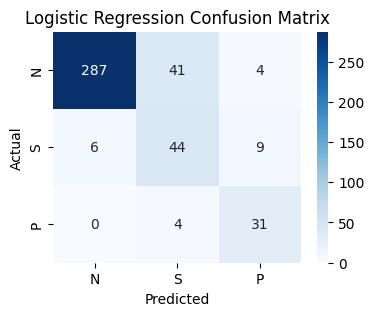


SVM (Linear)
              precision    recall  f1-score   support

           N       0.98      0.87      0.92       332
           P       0.70      0.89      0.78        35
           S       0.52      0.75      0.61        59

    accuracy                           0.86       426
   macro avg       0.73      0.83      0.77       426
weighted avg       0.89      0.86      0.87       426



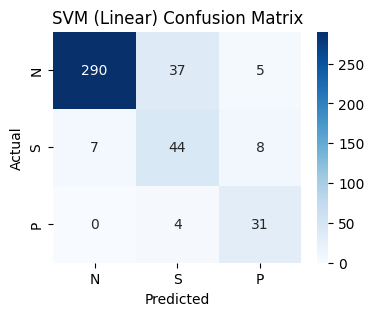


SVM (RBF)
              precision    recall  f1-score   support

           N       0.98      0.87      0.92       332
           P       0.79      0.89      0.84        35
           S       0.53      0.81      0.64        59

    accuracy                           0.87       426
   macro avg       0.77      0.86      0.80       426
weighted avg       0.90      0.87      0.88       426



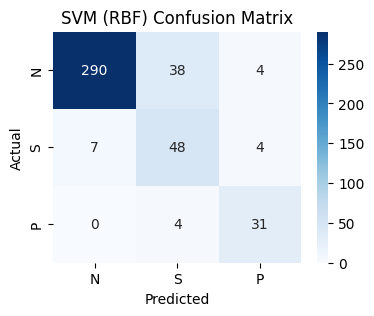


KNN
              precision    recall  f1-score   support

           N       0.98      0.89      0.93       332
           P       0.80      0.91      0.85        35
           S       0.58      0.83      0.68        59

    accuracy                           0.88       426
   macro avg       0.78      0.88      0.82       426
weighted avg       0.91      0.88      0.89       426



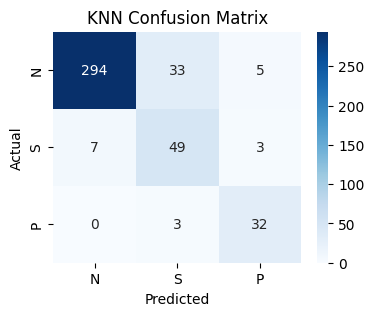


✅ All models trained successfully!


In [72]:
results = []
labels = ['N','S','P']
for name, model in pca_models.items(): 
    model.fit(X_train_pca_smote, y_train_pca_smote)
    y_pred = model.predict(X_test_pca)

    results.append({
        'Model': name, 
        'Data': 'PCA', 
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1 Macro': f1_score(y_test, y_pred, average='macro'),
        'F1 Weighted': f1_score(y_test, y_pred, average='weighted'),
        'Recall Macro': recall_score(y_test, y_pred, average='macro')
    })
    print("\n" + "==="*20)
    print(name)
    print("==="*20)
    print(classification_report(y_test,y_pred))


    # add confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, 
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=labels,
                yticklabels=labels)
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


print("\n" + "==="*20)
print("✅ All models trained successfully!")
print("==="*20)


#### Non-PCA Models Training


Decision Tree
              precision    recall  f1-score   support

           N       0.97      0.96      0.97       332
           P       0.86      0.91      0.89        35
           S       0.85      0.85      0.85        59

    accuracy                           0.94       426
   macro avg       0.89      0.91      0.90       426
weighted avg       0.94      0.94      0.94       426



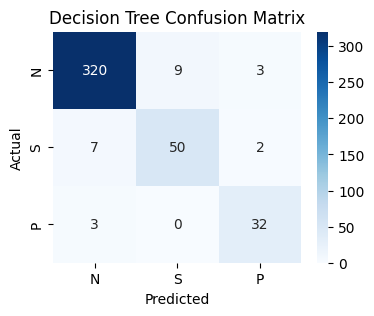


Random Forest
              precision    recall  f1-score   support

           N       0.97      0.97      0.97       332
           P       0.94      0.97      0.96        35
           S       0.83      0.81      0.82        59

    accuracy                           0.95       426
   macro avg       0.91      0.92      0.92       426
weighted avg       0.95      0.95      0.95       426



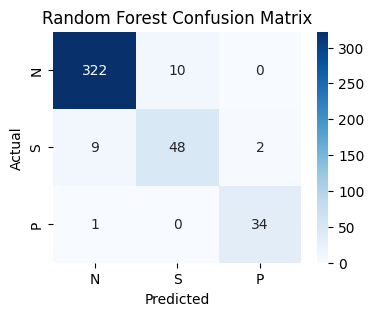


Gradient Boosting
              precision    recall  f1-score   support

           N       0.98      0.95      0.96       332
           P       0.94      0.97      0.96        35
           S       0.78      0.92      0.84        59

    accuracy                           0.95       426
   macro avg       0.90      0.95      0.92       426
weighted avg       0.95      0.95      0.95       426



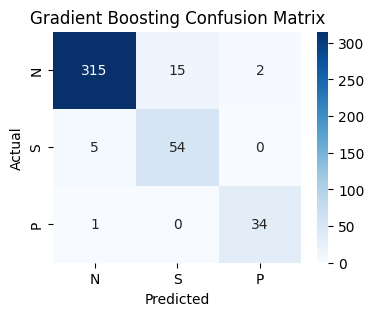


AdaBoost
              precision    recall  f1-score   support

           N       0.98      0.89      0.93       332
           P       0.92      0.97      0.94        35
           S       0.61      0.92      0.73        59

    accuracy                           0.90       426
   macro avg       0.84      0.92      0.87       426
weighted avg       0.92      0.90      0.90       426



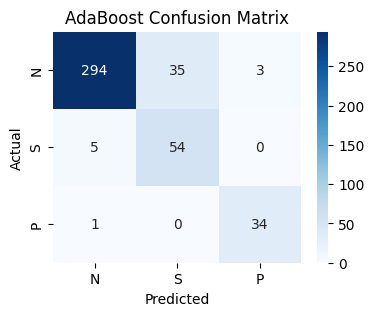


MLP
              precision    recall  f1-score   support

           N       0.97      0.95      0.96       332
           P       0.78      0.89      0.83        35
           S       0.75      0.78      0.77        59

    accuracy                           0.92       426
   macro avg       0.83      0.87      0.85       426
weighted avg       0.92      0.92      0.92       426



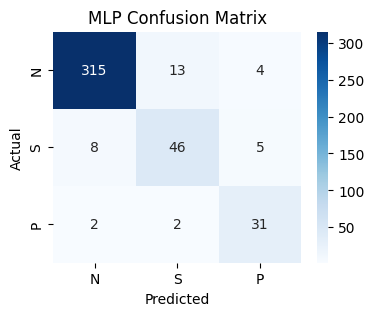


✅ All models trained successfully!


In [73]:
for name, model in non_pca_models.items(): 
    if name == 'MLP': 
        model.fit(X_train_scaled_smote, y_train_scaled_smote)
        y_pred = model.predict(X_test_scaled)
        data_type = 'Scaled'
    else: 
        model.fit(X_train_smote, y_train_smote)
        y_pred = model.predict(X_test)
        data_type = 'Original'

    results.append({
        'Model': name, 
        'Data': data_type, 
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1 Macro': f1_score(y_test, y_pred, average='macro'),
        'F1 Weighted': f1_score(y_test, y_pred, average='weighted'),
        'Recall Macro': recall_score(y_test, y_pred, average='macro')
    })
    print("\n" + "==="*20)
    print(name)
    print("==="*20)
    print(classification_report(y_test,y_pred))

    # add confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, 
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=labels,
                yticklabels=labels)
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

print("\n" + "==="*20)
print("✅ All models trained successfully!")
print("==="*20)

In [74]:
results_df = pd.DataFrame(results).sort_values(by='Recall Macro', ascending=False)
print(results_df)

                 Model      Data  Accuracy  F1 Macro  F1 Weighted  \
6    Gradient Boosting  Original  0.946009  0.922091     0.947438   
7             AdaBoost  Original  0.896714  0.868185     0.903746   
5        Random Forest  Original  0.948357  0.916046     0.948196   
4        Decision Tree  Original  0.943662  0.901038     0.943845   
3                  KNN       PCA  0.880282  0.820933     0.888304   
8                  MLP    Scaled  0.920188  0.850746     0.921415   
2            SVM (RBF)       PCA  0.866197  0.801411     0.876701   
1         SVM (Linear)       PCA  0.856808  0.772673     0.867748   
0  Logistic Regression       PCA  0.849765  0.765935     0.862578   

   Recall Macro  
6      0.945159  
7      0.924075  
5      0.918289  
4      0.908533  
3      0.876779  
8      0.871390  
2      0.857589  
1      0.834990  
0      0.831978  


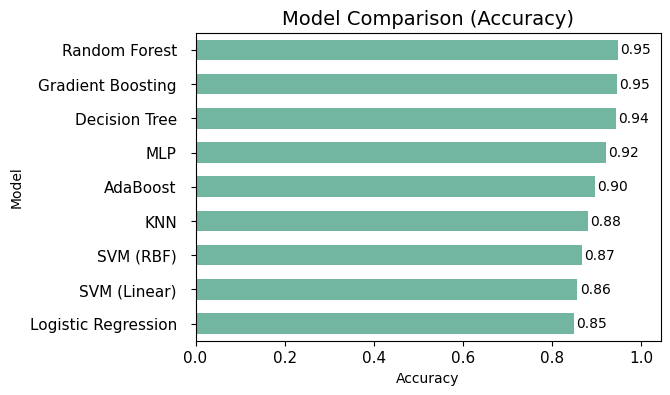

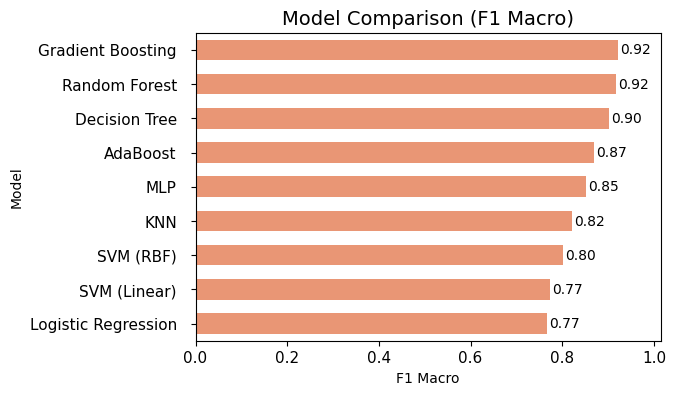

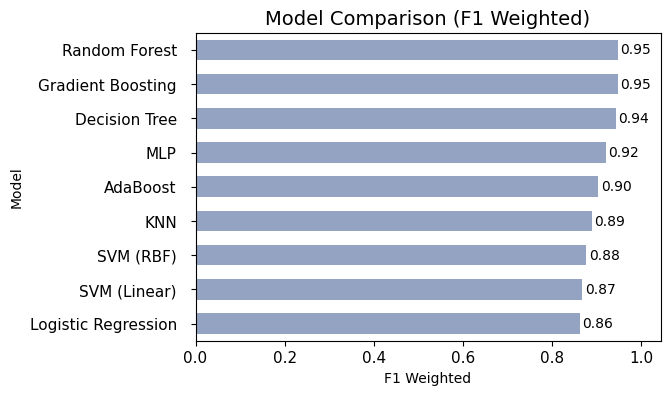

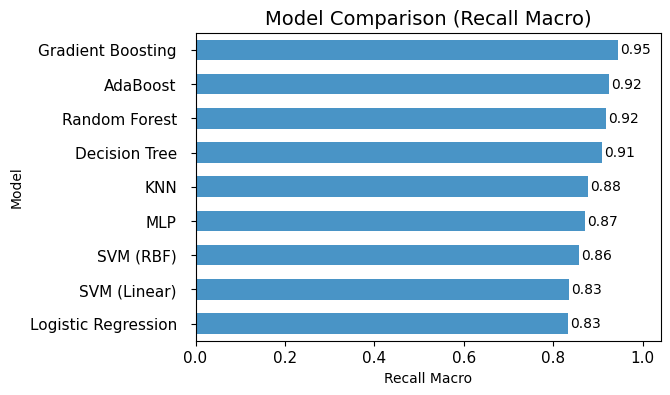

In [76]:
measures = ['Accuracy', 'F1 Macro', 'F1 Weighted', 'Recall Macro']
colors = ['#66C2A5','#FC8D62','#8DA0CB', '#3498db']

for measure, color in zip(measures, colors): 
    df_plot = results_df.sort_values(measure, ascending=False)

    plt.figure(figsize=(6,4))
    ax = sns.barplot(
        data=df_plot,
        x=measure,
        y='Model',
        color=color,
        width=0.6
    )
    ax.tick_params(axis='y', pad=10, labelsize=11)
    ax.tick_params(axis='x', labelsize=11)
    ax.margins(x=0.1)


    for i, v in enumerate(df_plot[measure].values):
        ax.text(v + 0.005, i, f"{v:.2f}", va='center')

    plt.title(f"Model Comparison ({measure})", fontsize=14)

    plt.show()

Across all three measures, Random Forest and Gradient Boosting ranked highest. In general, the tree models, especially ensemble, outperformed other simpler models. PCA sees to not have much effect on improving the model performance. 

## Fine Tuning + Validation

Initial baseline experiments across nine models showed tree-based ensemble methods (Random Forest and Gradient Boosting) significantly outperform linear, kernel, and instance-based learners.
Therefore hyperparameter optimization was focused on these top-performing candidates to improve efficiency and avoid unnecessary search over clearly sub-optimal model families. In order to minimize false negatives around classifying 'S' category, created a new scorer that will tune the model hyperparameters to acheive the goal. 

In [79]:
warnings.filterwarnings("ignore")

def recall_s(y_true, y_pred):
    return recall_score(y_true, y_pred, labels=['S'], average='macro')

s_recall_scorer = make_scorer(recall_s)


print("Optimizing models...\n")
cv_result = []

gb_pipeline = Pipeline([
    ('smote', SMOTE(random_state=random_state)),
    ('gb', GradientBoostingClassifier(random_state=random_state))
])


gb_param_grid = {
    'gb__n_estimators': [100, 200, 300],
    'gb__learning_rate': [0.03, 0.05, 0.1],
    'gb__max_depth': [2, 3, 4],
    'gb__subsample': [0.8,1.0]
}

print("RandomizedSearchCV on Gradient Boosting...\n")
gb_grid_cv = RandomizedSearchCV(estimator=gb_pipeline, 
                       param_distributions=gb_param_grid, 
                       n_iter=10,
                       scoring=s_recall_scorer, 
                       cv=5, 
                       n_jobs=-1,
                       random_state=random_state)

gb_grid_cv.fit(X_train, y_train)

best_gb_params = gb_grid_cv.best_params_
best_gb_model = gb_grid_cv.best_estimator_
y_gb_pred = best_gb_model.predict(X_test)

cv_result.append({"model": "Gradient Boosting",
                  "Best param": best_gb_params,
                  "Best score": gb_grid_cv.best_score_,
                  "Accuracy": accuracy_score(y_test, y_gb_pred),
                  "F1-macro": f1_score(y_test, y_gb_pred, average='macro'),
                  "F1-weighted": f1_score(y_test, y_gb_pred, average='weighted'),
                  "Recall-macro": recall_score(y_test, y_gb_pred, average='macro')})

print(f"Best model parameter: {best_gb_params}")
print(f"Best model CV score: {gb_grid_cv.best_score_}\n")
print(classification_report(y_test,y_gb_pred))


print("\n" + "==="*20)
print("==="*20 + "\n")


## Random Forest CV

rf_pipeline = Pipeline([
    ('smote', SMOTE(random_state=random_state)),
    ('rf', RandomForestClassifier(random_state=random_state))
])


rf_param_grid = {
    "rf__n_estimators": [200, 400, 600],
    "rf__max_depth": [None, 10, 20, 30],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4],
    "rf__max_features": ["sqrt", 0.5, 0.7]
}

print("RandomizedSearchCV on Gradient Boosting...\n")
rf_grid_cv = RandomizedSearchCV(estimator=rf_pipeline, 
                        param_distributions=rf_param_grid,
                        n_iter=15, 
                        scoring=s_recall_scorer, 
                        cv=5, 
                        n_jobs=-1,
                        random_state=random_state)

rf_grid_cv.fit(X_train, y_train)

best_rf_params = rf_grid_cv.best_params_
best_rf_model = rf_grid_cv.best_estimator_
y_rf_pred = best_rf_model.predict(X_test)

cv_result.append({"model": "Random Forest",
                  "Best param": best_rf_params,
                  "Best score": rf_grid_cv.best_score_,
                  "Accuracy": accuracy_score(y_test, y_rf_pred),
                  "F1-macro": f1_score(y_test, y_rf_pred, average='macro'),
                  "F1-weighted": f1_score(y_test, y_rf_pred, average='weighted'),
                  "Recall-macro": recall_score(y_test, y_rf_pred, average='macro')})

print(f"Best model parameter: {best_rf_params}")
print(f"Best model CV score: {rf_grid_cv.best_score_}\n")
print(classification_report(y_test,y_rf_pred))

print("✅ All models tuned successfully!")
print("Model performance comparison dataframe after Hyperparameter tuning: ")
display(pd.DataFrame(cv_result).round(4))



Optimizing models...

RandomizedSearchCV on Gradient Boosting...



/Users/yulmucho/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/yulmucho/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/yulmucho/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/yulmucho/Library/Python/

Best model parameter: {'gb__subsample': 1.0, 'gb__n_estimators': 100, 'gb__max_depth': 2, 'gb__learning_rate': 0.05}
Best model CV score: 0.8856382978723403

              precision    recall  f1-score   support

           N       0.97      0.89      0.93       332
           P       0.81      0.97      0.88        35
           S       0.66      0.88      0.75        59

    accuracy                           0.90       426
   macro avg       0.81      0.92      0.86       426
weighted avg       0.92      0.90      0.90       426



RandomizedSearchCV on Gradient Boosting...



/Users/yulmucho/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/yulmucho/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/yulmucho/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/yulmucho/Library/Python/

Best model parameter: {'rf__n_estimators': 400, 'rf__min_samples_split': 10, 'rf__min_samples_leaf': 2, 'rf__max_features': 0.5, 'rf__max_depth': 10}
Best model CV score: 0.8515957446808511

              precision    recall  f1-score   support

           N       0.98      0.92      0.95       332
           P       0.92      0.97      0.94        35
           S       0.68      0.86      0.76        59

    accuracy                           0.92       426
   macro avg       0.86      0.92      0.89       426
weighted avg       0.93      0.92      0.92       426

✅ All models tuned successfully!
Model performance comparison dataframe after Hyperparameter tuning: 


,model,Best param,Best score,Accuracy,F1-macro,F1-weighted,Recall-macro
0,Gradient Boosting,"{'gb__subsample': 1.0, 'gb__n_estimators': 100...",0.8856,0.8991,0.8564,0.9037,0.9158
1,Random Forest,"{'rf__n_estimators': 400, 'rf__min_samples_spl...",0.8516,0.9202,0.8854,0.9238,0.9202


Gradient Boosting performed the best. 

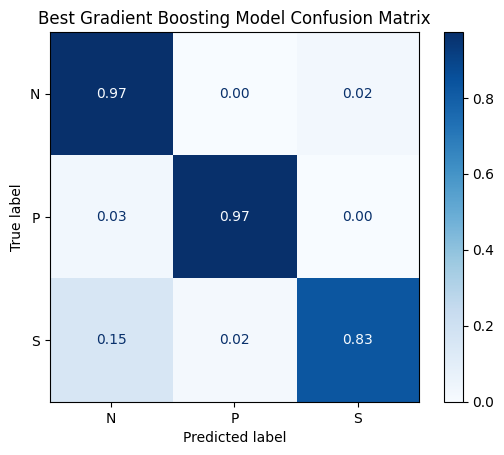

In [ ]:
cm_best = confusion_matrix(y_test, 
                           y_gb_pred, 
                           labels=best_gb_model.classes_,
                           normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm_best,
                              display_labels=best_gb_model.classes_)


disp.plot(cmap='Blues', values_format='.2f')

plt.title("Best Gradient Boosting Model Confusion Matrix")
plt.show()